# Taller 1 — Macroeconomía 3: Ciclos Económicos

**Objetivo:** Este notebook es la Fase 1 (Punto 1) del taller. Cargamos y exploramos datos macroeconómicos de Estados Unidos (FRED), generamos estadísticas descriptivas, visualizamos 7 series económicas trimestrales e identificamos períodos con variación negativa del PIB real.

## 1. Paths & Folders (Detección automática y creación)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Detect ROOT by searching upwards for 'data' folder
current = Path.cwd()
ROOT = None

for parent in current.parents:
    if (parent / 'data').exists():
        ROOT = parent
        break

if ROOT is None:
    if (current / 'data').exists():
        ROOT = current
    else:
        raise FileNotFoundError("Could not find 'data' folder. Please run from project root.")

# Define paths
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
OUT_FIG = ROOT / 'outputs' / 'figures'
OUT_TAB = ROOT / 'outputs' / 'tables'
OUT_EXP = ROOT / 'outputs' / 'exports'

# Create directories if they don't exist
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_EXP.mkdir(parents=True, exist_ok=True)

print("Directorios verificados y listos para outputs.")

Directorios verificados y listos para outputs.


## 2. Decisiones Económicas: País, Variables y Transformaciones

### País y Fuente de Datos
**Estados Unidos (FRED)** con frecuencia objetivo **trimestral**.

### Motivación
1. **Disponibilidad y calidad:** El Federal Reserve Economic Data (FRED) ofrece series de alta calidad y consistencia temporal.
2. **Evaluación del filtro HP:** Utilizamos un país desarrollado para validar cómo se ajusta el filtro Hodrick-Prescott en una economía madura.
3. **Comparación conceptual:** Exploraremos si las dinámicas económicas estadounidenses difieren significativamente de las observadas en Colombia, permitiendo futuros análisis comparativos.

### Variables Elegidas
- **GDP (Producto Interno Bruto real):** Medida de actividad económica agregada.
- **Consumo (PCECC96):** Gasto en consumo personal en dólares encadenados 2012.
- **Inversión (GPDIC1):** Inversión fija privada doméstica en dólares encadenados 2012.
- **Desempleo (UNRATE):** Tasa de desempleo (porcentaje).
- **Inflación (GDPDEF):** Deflactor del PIB, refleja cambios de precios en la economía.
- **Tasa de política (FEDFUNDS):** Tasa de fondos federales, herramienta de política monetaria de la Fed.

### Propósito
1. **Corto plazo:** Estudiar brechas de componentes del PIB (tendencia vs. ciclo) para entender dinámicas de consumo e inversión.
2. **Extensión futura:** Explorar relaciones empíricas entre brecha del PIB, desempleo e inflación (curva de Phillips, ley de Okun).

### Transformaciones Aplicadas
- **UNRATE y FEDFUNDS (mensual → trimestral):** Promedio simple de tres observaciones mensuales por trimestre.
- **GDP Var (tasa de crecimiento anualizada):** $\text{GDP Var} = 400 \times \Delta \log(\text{GDP})$
- **Inflación (tasa anualizada):** $\text{inflation} = 400 \times \Delta \log(\text{GDPDEF})$

## 3. Cargar Dataset Limpio

In [2]:
# Load dataset from processed folder
xlsx_file = DATA_PROC / 'dataset_taller.xlsx'
csv_file = DATA_PROC / 'dataset_taller.csv'

if xlsx_file.exists():
    df = pd.read_excel(xlsx_file)
elif csv_file.exists():
    df = pd.read_csv(csv_file)
else:
    raise FileNotFoundError(f"Neither {xlsx_file} nor {csv_file} found.")

# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Dataset: {df.shape[0]} filas × {df.shape[1]} columnas | Periodo: {df['date'].min().date()} a {df['date'].max().date()}\n")
print(df.head())

Dataset: 285 filas × 8 columnas | Periodo: 1954-12-31 a 2025-12-31

        date       GDP    GDP Var  consumption  investment  unemployment  \
0 1954-12-31  2936.852   7.752247     1761.703     295.882      5.333333   
1 1955-03-31  3020.746  11.266225     1801.231     325.442      4.733333   
2 1955-06-30  3069.910   6.457770     1835.737     345.235      4.400000   
3 1955-09-30  3111.379   5.367116     1858.411     350.533      4.100000   
4 1955-12-31  3130.068   2.395477     1881.748     358.661      4.233333   

   inflation  fedfunds  
0   1.088836  0.986667  
1   1.876424  1.343333  
2   1.634681  1.500000  
3   2.786861  1.940000  
4   3.943755  2.356667  


In [3]:
# Data types
print("Tipos de datos:")
print(df.dtypes)

# Validate no missing values in required columns
required_cols = ['GDP', 'GDP Var', 'consumption', 'investment', 'unemployment', 'inflation', 'fedfunds']
assert df[required_cols].isna().sum().sum() == 0, "Valores faltantes detectados en columnas requeridas"

print("\nSin valores faltantes en columnas requeridas.")

Tipos de datos:
date            datetime64[us]
GDP                    float64
GDP Var                float64
consumption            float64
investment             float64
unemployment           float64
inflation              float64
fedfunds               float64
dtype: object

Sin valores faltantes en columnas requeridas.


## 4. Tabla Descriptiva

In [4]:
# Calculate descriptive statistics (exclude date)
desc = df.drop(columns=['date']).describe().round(2)

# Save to Excel and CSV
desc.to_excel(OUT_TAB / 'descriptivas.xlsx')
desc.to_csv(OUT_TAB / 'descriptivas.csv')

# Display table
display(desc)

,GDP,GDP Var,consumption,investment,unemployment,inflation,fedfunds
count,285.00,285.00,285.00,285.00,285.00,285.00,285.00
mean,11171.05,2.98,7325.78,1724.60,5.80,3.18,4.62
std,6132.25,4.29,4296.59,1206.13,1.67,2.26,3.53
min,2936.85,-32.82,1761.70,288.01,3.40,-1.60,0.06
25%,5814.85,1.36,3627.90,669.44,4.50,1.66,1.94
50%,9998.70,3.07,6353.14,1279.70,5.53,2.48,4.33
75%,16561.87,4.65,11158.80,2638.67,6.83,4.03,6.22
max,24111.83,29.90,16682.49,4547.95,13.00,11.60,17.78


## 5. Gráficos Individuales por Variable (7 Series)

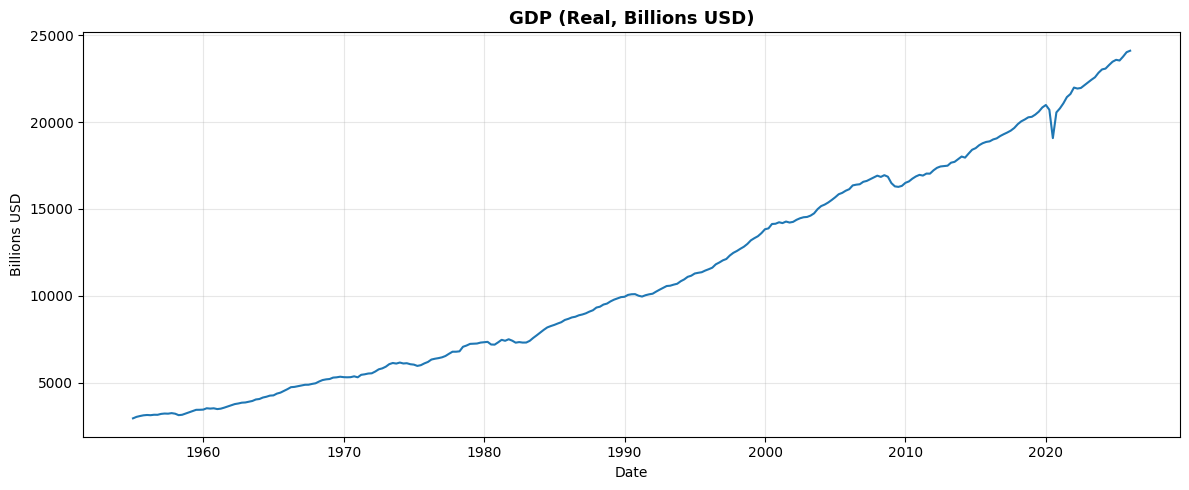

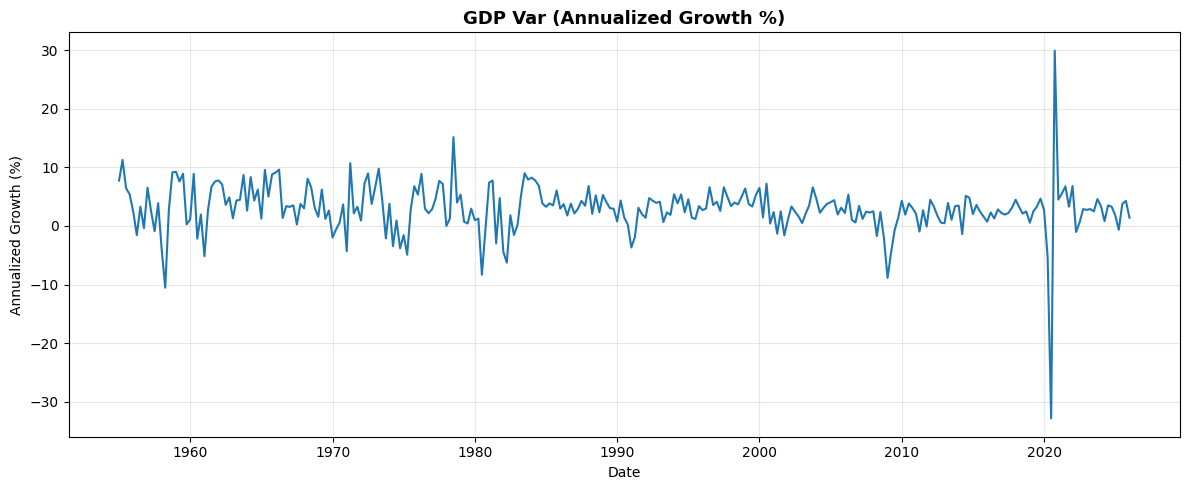

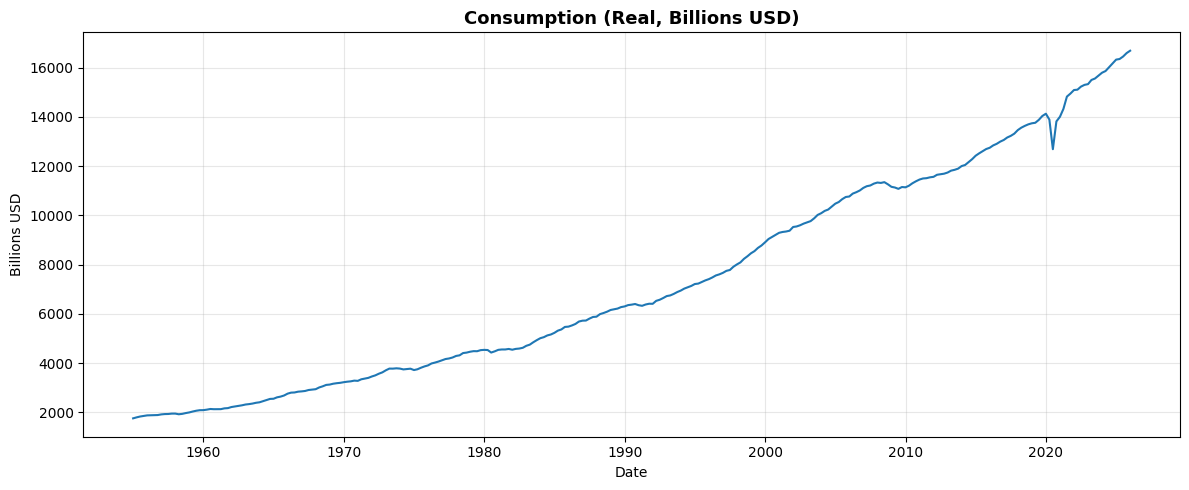

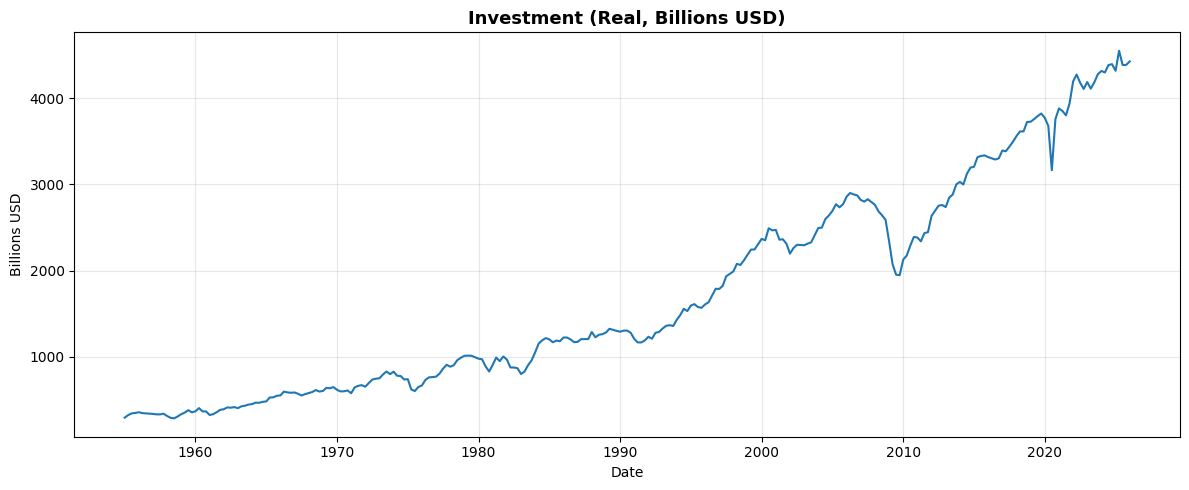

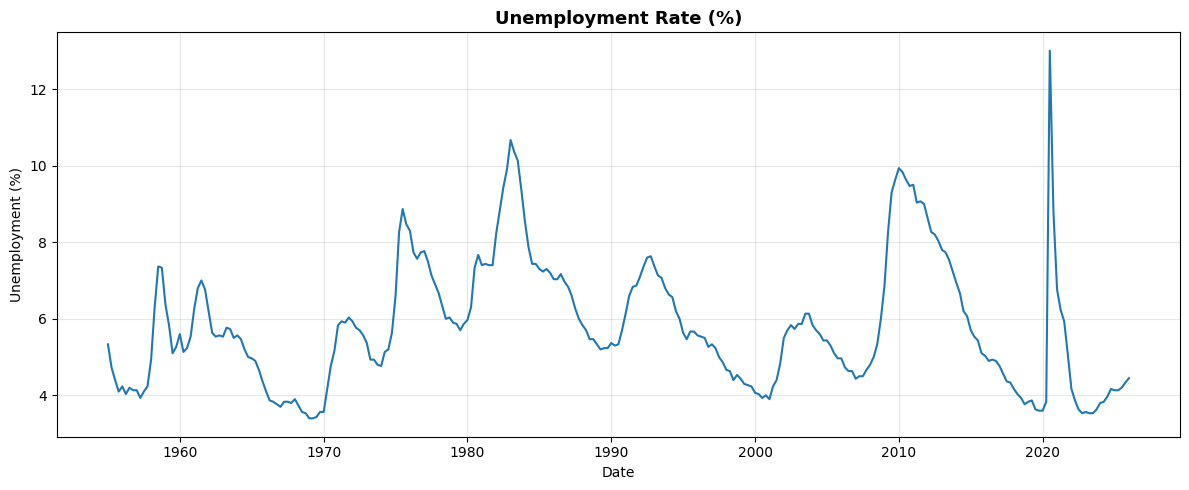

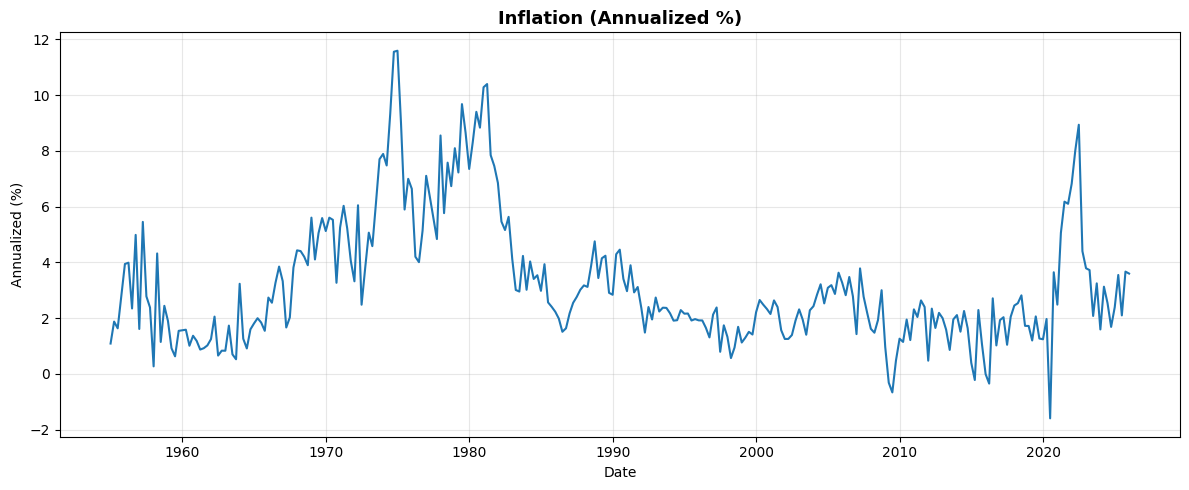

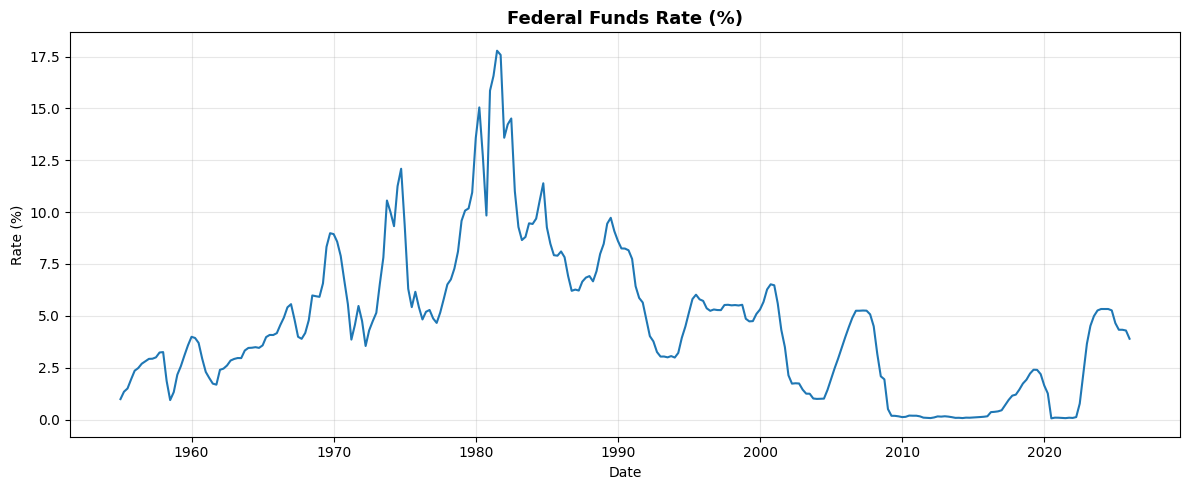

In [5]:
# Function to create, save and display plots
def plot_and_save(df, col, title, ylabel, filename):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df['date'], df[col], linewidth=1.5)
    ax.set_xlabel('Date')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    fig_path = OUT_FIG / filename
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Plot 7 variables
variables = [
    ('GDP', 'GDP (Real, Billions USD)', 'Billions USD', '01_GDP.png'),
    ('GDP Var', 'GDP Var (Annualized Growth %)', 'Annualized Growth (%)', '02_GDP_Var.png'),
    ('consumption', 'Consumption (Real, Billions USD)', 'Billions USD', '03_consumption.png'),
    ('investment', 'Investment (Real, Billions USD)', 'Billions USD', '04_investment.png'),
    ('unemployment', 'Unemployment Rate (%)', 'Unemployment (%)', '05_unemployment.png'),
    ('inflation', 'Inflation (Annualized %)', 'Annualized (%)', '06_inflation.png'),
    ('fedfunds', 'Federal Funds Rate (%)', 'Rate (%)', '07_fedfunds.png')
]

for col, title, ylabel, filename in variables:
    plot_and_save(df, col, title, ylabel, filename)

## 6. Tabla de Períodos con GDP Var < 0

In [6]:
# Create recession table
df_neg = df[df['GDP Var'] < 0][['date', 'GDP Var']].copy()

# Prepare for export (convert date to date-only)
df_neg_export = df_neg.copy()
df_neg_export['date'] = df_neg_export['date'].dt.date

# Save to Excel and CSV
df_neg_export.to_excel(OUT_TAB / 'gdp_var_negativa.xlsx', index=False)
df_neg_export.to_csv(OUT_TAB / 'gdp_var_negativa.csv', index=False)

# Display results
print(f"Total de trimestres con GDP Var < 0: {len(df_neg)}\n")
print("Primeros 10 trimestres:")
print(df_neg.head(10))
print()

# Display full table in notebook
display(df_neg)

Total de trimestres con GDP Var < 0: 37

Primeros 10 trimestres:
         date    GDP Var
5  1956-03-31  -1.555190
7  1956-09-30  -0.358975
10 1957-06-30  -0.877523
12 1957-12-31  -4.159708
13 1958-03-31 -10.520768
22 1960-06-30  -2.159247
24 1960-12-31  -5.165738
60 1969-12-31  -1.957619
61 1970-03-31  -0.596011
64 1970-12-31  -4.309423



,date,GDP Var
5,1956-03-31,-1.555190
7,1956-09-30,-0.358975
10,1957-06-30,-0.877523
12,1957-12-31,-4.159708
13,1958-03-31,-10.520768
22,1960-06-30,-2.159247
24,1960-12-31,-5.165738
60,1969-12-31,-1.957619
61,1970-03-31,-0.596011
64,1970-12-31,-4.309423


### Análisis de Volatilidad Extrema en GDP Var

In [7]:
# Find periods of maximum and minimum GDP Var
max_idx = df['GDP Var'].idxmax()
min_idx = df['GDP Var'].idxmin()

max_val = df.loc[max_idx, 'GDP Var']
min_val = df.loc[min_idx, 'GDP Var']
max_date = df.loc[max_idx, 'date']
min_date = df.loc[min_idx, 'date']

# Create summary table
extremes = pd.DataFrame({
    'Período': ['Máxima Expansión', 'Máxima Contracción'],
    'Fecha': [max_date.strftime('%Y-%m-%d'), min_date.strftime('%Y-%m-%d')],
    'GDP Var (%)': [max_val, min_val]
})

print("VOLATILIDAD EXTREMA EN GDP VAR")
print("=" * 60)
print(f"Máxima Expansión:   {max_date.strftime('%Y-%m-%d')} | GDP Var: {max_val:.2f}%")
print(f"Máxima Contracción: {min_date.strftime('%Y-%m-%d')} | GDP Var: {min_val:.2f}%")
print(f"Amplitud Total:     {max_val - min_val:.2f} puntos porcentuales")
print("=" * 60)
print()

display(extremes)

VOLATILIDAD EXTREMA EN GDP VAR
Máxima Expansión:   2020-09-30 | GDP Var: 29.90%
Máxima Contracción: 2020-06-30 | GDP Var: -32.82%
Amplitud Total:     62.72 puntos porcentuales



,Período,Fecha,GDP Var (%)
0,Máxima Expansión,2020-09-30,29.902999
1,Máxima Contracción,2020-06-30,-32.817282


## Interpretación descriptiva (Punto 1)

### Cobertura y consistencia de datos
La muestra cubre el periodo **1954Q4–2025Q4** (frecuencia trimestral). Las series de nivel (**GDP real, consumo real e inversión real**) muestran una tendencia creciente de largo plazo, mientras que las series de tasa (**desempleo, inflación y tasa de política**) exhiben cambios de régimen y episodios de alta volatilidad.

### Volatilidad relativa
En niveles, **GDP, consumption e investment** están dominadas por crecimiento secular; por eso, visualmente los ciclos aparecen como desviaciones relativamente pequeñas alrededor de una tendencia. En contraste, **GDP Var** (crecimiento trimestral anualizado) es altamente volátil: al diferenciar (Δlog) se elimina gran parte de la tendencia y se amplifica la variación de corto plazo.

Comparando **consumo vs inversión**, la inversión muestra fluctuaciones más pronunciadas: cae más en episodios recesivos y se recupera con mayor amplitud. Esto es coherente con hechos estilizados de ciclos: la inversión suele ser el componente más sensible a shocks y condiciones financieras, mientras el consumo es más “suave”.

### Episodios macroeconómicos identificables en las gráficas
**(i) COVID-19 (2020): shock extremo y reversión rápida**  
El periodo de pandemia concentra los extremos principales de varias series:
- **Mayor contracción:** 2020-06-30 con **GDP Var = -32.82%** (anualizado).
- **Mayor expansión (rebote):** 2020-09-30 con **GDP Var = 29.90%**.
- **Inflación mínima (deflación):** 2020-06-30 con **inflation = -1.60%**.
- **Desempleo máximo:** 2020-06-30 con **unemployment = 13.0%**.
- **Tasa de política mínima:** 2020-06-30 con **fedfunds = 0.06%**.

Este patrón (colapso + rebote inmediato) es consistente con un shock transitorio muy fuerte (cierres) seguido por reapertura y respuesta macroeconómica expansiva.

**(ii) Régimen de alta inflación (1970s)**  
La inflación anualizada alcanza su máximo en **1974-12-31** con **inflation = 11.60%**, consistente con el episodio de alta inflación asociado a shocks de oferta y tensiones macro del periodo.

**(iii) Política monetaria extremadamente contractiva (inicio de 1980s)**  
La tasa Fed Funds alcanza su máximo en **1981-06-30** con **fedfunds = 17.78%**, coherente con el endurecimiento monetario del inicio de los 80s para reducir la inflación (“Volcker disinflation”).

### Coherencia macroeconómica entre actividad y desempleo
La relación cualitativa entre actividad y desempleo es coherente con la intuición de ciclos: cuando el crecimiento cae fuertemente (**GDP Var** negativa), el desempleo aumenta (posiblemente con rezago). Esto se observa de forma clara en 2020-06-30, donde el mínimo de GDP Var coincide con el máximo de unemployment.

### Periodos de contracción: `GDP Var < 0`
Al filtrar trimestres con **GDP Var < 0**, se identifican **37 trimestres** de contracción en la muestra. Importante: esto no equivale automáticamente a “37 recesiones”, ya que una recesión es un episodio que suele agrupar varios trimestres consecutivos. Aun así, esta tabla sirve como indicador simple para ubicar periodos de desaceleración/contracción.

### Preparación para Fase 2 (Filtro HP)
Los candidatos naturales para separar tendencia y ciclo son las series en niveles con tendencia fuerte: **GDP, consumption e investment** (idealmente en logaritmos). En contraste, **GDP Var** e **inflation** ya son tasas de cambio y **unemployment** y **fedfunds** son tasas; aplicar HP allí puede ser menos informativo si no se justifica cuidadosamente.

## 8. Verificación de Outputs Generados

In [8]:
# List generated outputs with relative paths
print("ARCHIVOS GENERADOS")
print("=" * 60)

print("\nTablas (outputs/tables/):")
for f in sorted(OUT_TAB.glob('*')):
    if f.is_file():
        print(f"  • {f.name}")

print("\nGráficos (outputs/figures/):")
for f in sorted(OUT_FIG.glob('*.png')):
    print(f"  • {f.name}")
    
print("\n✓ Notebook completado exitosamente.")

ARCHIVOS GENERADOS

Tablas (outputs/tables/):
  • descriptivas.csv
  • descriptivas.xlsx
  • gdp_var_negativa.csv
  • gdp_var_negativa.xlsx

Gráficos (outputs/figures/):
  • 01_GDP.png
  • 02_GDP_Var.png
  • 03_consumption.png
  • 04_investment.png
  • 05_unemployment.png
  • 06_inflation.png
  • 07_fedfunds.png

✓ Notebook completado exitosamente.
